[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/0b_BinaryClassification_Titanic_TrainValTest.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video (M2.3 bonus) - Titanic done right: train / validation / test

- Students ask this EVERY year: "what's the difference between validation_split and a test set?" This whole video is that answer.
- Three piles, three jobs: train = study material, validation = practice exams (steers early stopping), test = the FINAL exam, opened once.
- validation_split carves the val set out of whatever you hand fit(); validation_data hands Keras YOUR fixed val set - same idea, more control, and now the test set is untouched by either.
- stratify=Y: every pile gets the same 62/38 death/survival mix - cheap insurance, one keyword.
- Punchline at the metrics table: train >= val ~ test. The TEST number is the only one you report. And it still has to beat the 62% dummy baseline!
-->

# Titanic Done Right: Train / Validation / Test
-------------------------------
**Dr. Dave Wanik**

In the main Titanic notebook we trained on ALL the data and graded ourselves on that same data... and I told you the fix was a held-out test set. Students then ask (every year!): *"but the model already had `validation_split`... isn't that the test set?"*

**NO! And this notebook is the difference.** We're going to cut the data into THREE piles:

* **Train (60%)** - the study material. The model learns its weights here.
* **Validation (20%)** - the practice exams. The model never trains on it, but WE use it every epoch to steer early stopping... so information leaks in through our decisions.
* **Test (20%)** - the final exam. Locked in a vault until the very end, opened ONCE.

In [1]:
# modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

## Data prep - fast forward
Same cleanup as the main Titanic notebook, compressed into one cell.

In [2]:
# same cleanup as the main Titanic notebook - fast-forwarded into one cell
# (go watch that video if any line here is mysterious!)

# read the data
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/titanic_train.csv"
df = pd.read_csv(url)

# delete the cabin column, impute Age with the mean (assign it back!),
# then ditch the two rows with a missing 'Embarked'
df.drop(['Cabin'], axis=1, inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.dropna(inplace=True)

# drop the columns that don't help, recode the words into numbers
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df['Sex'] = df['Sex'].replace(('male', 'female'), (0, 1))
df['Embarked'] = df['Embarked'].replace(('Q', 'S', 'C'), (0, 1, 2))

# split into X and Y, force a real numeric dtype (Keras 3 demands it)
Y = df['Survived']
X = df.drop(['Survived'], axis=1)
X = np.array(X).astype('float32')
Y = np.array(Y).astype('float32')

print(X.shape, Y.shape)  # voila! 889 rows, ready for modeling

(889, 7) (889,)


## Cut the three piles

Two `train_test_split` calls back to back: first peel off the 20% test vault, then split what's left into train and validation. And note `stratify=Y` - it guarantees every pile gets the same 62/38 died/survived mix. One keyword, cheap insurance.

In [3]:
# first cut: lock 20% in the test vault
X_temp, X_test, y_temp, y_test = train_test_split(X, Y,
                                                  test_size=0.2,
                                                  random_state=123,
                                                  stratify=Y)

# second cut: split the remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,
                                                  test_size=0.25, # 0.25 x 0.8 = 0.2 of the total!
                                                  random_state=123,
                                                  stratify=y_temp)

print('train:', X_train.shape, ' val:', X_val.shape, ' test:', X_test.shape)

# prove the stratify worked - same survival rate in every pile!
print('survival rate - train: %.3f  val: %.3f  test: %.3f' %
      (y_train.mean(), y_val.mean(), y_test.mean()))

train: (533, 7)  val: (178, 7)  test: (178, 7)
survival rate - train: 0.383  val: 0.382  test: 0.382


## Build and fit - with `validation_data` this time

Same 16-16-1 architecture as the main notebook. The ONE new idea: instead of `validation_split=0.2` (where Keras carves the validation set out of whatever you hand it), we pass `validation_data=(X_val, y_val)` - OUR fixed pile. Early stopping watches it, the test vault stays sealed.

In [4]:
# fresh model, same architecture as the main notebook
keras.backend.clear_session()

model = Sequential()
model.add(Dense(16, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# early stopping watches the VALIDATION pile
es = EarlyStopping(monitor='val_accuracy',
                   mode='max',
                   patience=20,
                   restore_best_weights=True)

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_val, y_val), # <- the new part!
                    callbacks=[es],
                    epochs=1000,
                    batch_size=10,
                    shuffle=True,
                    verbose=1)

Epoch 1/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.4000 - loss: 4.9021

41/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5146 - loss: 2.0936

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5741 - loss: 1.7601 - val_accuracy: 0.6685 - val_loss: 0.7162


Epoch 2/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.5224

32/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.7133 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6904 - loss: 0.6925 - val_accuracy: 0.6685 - val_loss: 0.6131


Epoch 3/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.6194

40/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6850 - loss: 0.6261 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6848 - loss: 0.6288 - val_accuracy: 0.7079 - val_loss: 0.5969


Epoch 4/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7000 - loss: 0.6061

29/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7172 - loss: 0.5973 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7054 - loss: 0.5974 - val_accuracy: 0.7079 - val_loss: 0.5828


Epoch 5/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9000 - loss: 0.3174

36/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7139 - loss: 0.6184 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7186 - loss: 0.6013 - val_accuracy: 0.6854 - val_loss: 0.5763


Epoch 6/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7000 - loss: 0.6033

28/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7357 - loss: 0.5763 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7167 - loss: 0.5879 - val_accuracy: 0.6854 - val_loss: 0.5780


Epoch 7/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6000 - loss: 0.5209

44/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7227 - loss: 0.5714 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7261 - loss: 0.5728 - val_accuracy: 0.7079 - val_loss: 0.5686


Epoch 8/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9000 - loss: 0.2974

38/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7079 - loss: 0.5878 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7129 - loss: 0.5847 - val_accuracy: 0.7247 - val_loss: 0.5550


Epoch 9/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7000 - loss: 0.5599

33/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7364 - loss: 0.5657 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7392 - loss: 0.5841 - val_accuracy: 0.7079 - val_loss: 0.5993


Epoch 10/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7000 - loss: 0.5046

35/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7371 - loss: 0.5980 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7392 - loss: 0.5842 - val_accuracy: 0.7079 - val_loss: 0.5655


Epoch 11/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6000 - loss: 0.6637

36/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7556 - loss: 0.5411 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7448 - loss: 0.5479 - val_accuracy: 0.7022 - val_loss: 0.5794


Epoch 12/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8000 - loss: 0.5588

41/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7439 - loss: 0.5487 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7373 - loss: 0.5577 - val_accuracy: 0.6910 - val_loss: 0.5872


Epoch 13/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9000 - loss: 0.4400

37/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7595 - loss: 0.5641 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7674 - loss: 0.5521 - val_accuracy: 0.7303 - val_loss: 0.5601


Epoch 14/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.4306

31/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7387 - loss: 0.5606 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7261 - loss: 0.5804 - val_accuracy: 0.7360 - val_loss: 0.5560


Epoch 15/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7000 - loss: 0.4082

37/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7432 - loss: 0.5503 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7617 - loss: 0.5344 - val_accuracy: 0.7472 - val_loss: 0.5191


Epoch 16/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.2638

34/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.5048 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7767 - loss: 0.4991 - val_accuracy: 0.7584 - val_loss: 0.5152


Epoch 17/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8000 - loss: 0.4944

36/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8083 - loss: 0.4741 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7955 - loss: 0.4959 - val_accuracy: 0.7472 - val_loss: 0.5310


Epoch 18/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6000 - loss: 0.6210

35/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8171 - loss: 0.4660 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7917 - loss: 0.4943 - val_accuracy: 0.7472 - val_loss: 0.5235


Epoch 19/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9000 - loss: 0.2726

33/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7333 - loss: 0.9410 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7542 - loss: 0.8006 - val_accuracy: 0.7921 - val_loss: 0.5063


Epoch 20/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.2661

28/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7571 - loss: 0.5722 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7842 - loss: 0.5346 - val_accuracy: 0.7584 - val_loss: 0.5124


Epoch 21/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7000 - loss: 0.5475

35/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7971 - loss: 0.4811 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4834 - val_accuracy: 0.7416 - val_loss: 0.5007


Epoch 22/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7000 - loss: 0.6414

31/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7806 - loss: 0.5104 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7805 - loss: 0.5160 - val_accuracy: 0.7584 - val_loss: 0.4935


Epoch 23/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8000 - loss: 0.4224

29/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8103 - loss: 0.4827 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8011 - loss: 0.4635 - val_accuracy: 0.7416 - val_loss: 0.5055


Epoch 24/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9000 - loss: 0.1663

34/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4580 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7880 - loss: 0.4780 - val_accuracy: 0.7472 - val_loss: 0.5622


Epoch 25/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9000 - loss: 0.3497

38/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8053 - loss: 0.4533 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7955 - loss: 0.4773 - val_accuracy: 0.7584 - val_loss: 0.5137


Epoch 26/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9000 - loss: 0.2473

37/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8081 - loss: 0.4491 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8068 - loss: 0.4635 - val_accuracy: 0.7472 - val_loss: 0.5673


Epoch 27/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8000 - loss: 0.4740

44/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7750 - loss: 0.5068 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7805 - loss: 0.4968 - val_accuracy: 0.7584 - val_loss: 0.4974


Epoch 28/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7000 - loss: 0.4206

44/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8114 - loss: 0.4558 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4660 - val_accuracy: 0.7528 - val_loss: 0.5413


Epoch 29/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8000 - loss: 0.2559

33/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4247 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7786 - loss: 0.4681 - val_accuracy: 0.7809 - val_loss: 0.4946


Epoch 30/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6000 - loss: 0.7395

37/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7784 - loss: 0.5191 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7955 - loss: 0.4949 - val_accuracy: 0.7472 - val_loss: 0.5124


Epoch 31/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9000 - loss: 0.2747

34/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8029 - loss: 0.4903 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8049 - loss: 0.4748 - val_accuracy: 0.7472 - val_loss: 0.4911


Epoch 32/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8000 - loss: 0.4278

26/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7962 - loss: 0.4574 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4567 - val_accuracy: 0.7528 - val_loss: 0.4878


Epoch 33/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9000 - loss: 0.3507

44/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8023 - loss: 0.4633 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8086 - loss: 0.4554 - val_accuracy: 0.7472 - val_loss: 0.4999


Epoch 34/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7000 - loss: 0.4838

38/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7947 - loss: 0.4573 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7992 - loss: 0.4512 - val_accuracy: 0.7528 - val_loss: 0.4905


Epoch 35/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7000 - loss: 0.6239

31/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7903 - loss: 0.4298 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7880 - loss: 0.4675 - val_accuracy: 0.7472 - val_loss: 0.5119


Epoch 36/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9000 - loss: 0.3274

29/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8276 - loss: 0.4444 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8030 - loss: 0.4715 - val_accuracy: 0.7640 - val_loss: 0.4937


Epoch 37/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9000 - loss: 0.3844

35/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7886 - loss: 0.5053 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8124 - loss: 0.4570 - val_accuracy: 0.7697 - val_loss: 0.4964


Epoch 38/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9000 - loss: 0.2357

30/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.4460 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8049 - loss: 0.4554 - val_accuracy: 0.7472 - val_loss: 0.5538


Epoch 39/1000


 1/54 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7000 - loss: 0.5381

35/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7600 - loss: 0.5687 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7861 - loss: 0.5140 - val_accuracy: 0.7528 - val_loss: 0.4968


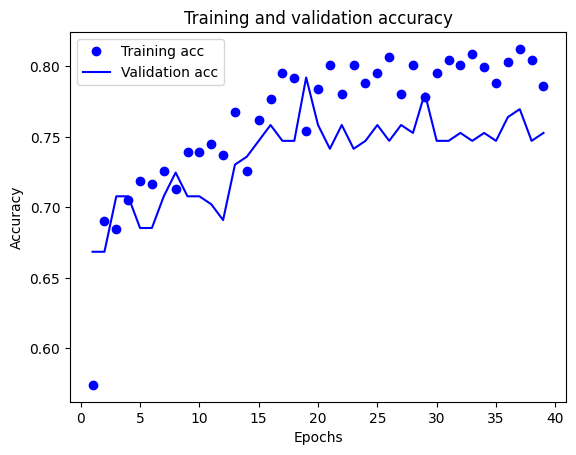

In [6]:
# learning curve - train vs validation accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Open the vault!

Moment of truth. Score all three piles - then remember which number you're allowed to brag about.

In [7]:
# score all three partitions
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc   = model.evaluate(X_test, y_test, verbose=0)

pd.DataFrame({'partition': ['train', 'validation', 'test'],
              'accuracy':  [round(train_acc, 3), round(val_acc, 3), round(test_acc, 3)]})

,partition,accuracy
0,train,0.803
1,validation,0.792
2,test,0.781


In [8]:
# confusion matrix + classification report - TEST PILE ONLY
preds = np.round(model.predict(X_test), 0)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


[[94 16]
 [23 45]]
              precision    recall  f1-score   support

         0.0       0.80      0.85      0.83       110
         1.0       0.74      0.66      0.70        68

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



💡 See the pattern? **Train ≥ validation ≈ test.** The model knows the study material best, the practice exams a bit less, and the final exam about the same as the practice exams - which is exactly what "generalizes" looks like. If train were WAY above the other two, that's overfitting. If validation were way above test... you got lucky on your practice exams.

**The test number is the ONLY one you report.** And check it against the dummy baseline: always-predict-died scores 62%, so everything above that is what your network actually earned.

# On Your Own
* Change `random_state` to a few different values and re-run. Watch the test accuracy wiggle by a couple points - one split is ONE lottery ticket. (That's the whole reason the k-fold notebook exists... go there next!)
* Remove `stratify` from both splits and check the three survival rates again. How lopsided can they get?
* Make the test vault bigger (30%? 40%?). More trustworthy final exam, less study material... where's the sweet spot for 889 rows?